# Confounding Diffusion Analysis

Compares the predicted-noise divergence between models trained on clean vs. confounded IHDP,
for two model families: naive `DiffPO` (`naive_full` / `naive_conf`) and `HybridModel`
(`hybrid_full` / `hybrid_conf`). Tests whether the latent `z` shrinks the confounding
footprint.

## Setup

Loads the config and all four checkpoints, loads both data conditions, and defines a
`run_family` pipeline that produces the cross-evaluated divergence and point-estimate errors
for one model family. Run over the full IHDP test split; every claim is reported stratified
by `momblack`.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import torch
import yaml
from mpl_toolkits.mplot3d.axes3d import Axes3D
from scipy.stats import gaussian_kde, linregress, permutation_test

from src.config import Config
from src.confounding_analysis import (
    bootstrap_curve,
    cross_evaluate,
    divergence_ratio,
    pointwise_ci,
)
from src.data import load_ihdp, make_ihdp_confounded
from src.model import DiffPO, HybridModel, _DiffusionBase

/home/justin/msc_ai/individual-project/diffusion-irregular-ehr/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
CHECKPOINTS = {
    "naive": {
        "cls": DiffPO,
        "full": "checkpoints/final_model_naive_full_2026-08-03T16_21_12.pth",
        "conf": "checkpoints/final_model_naive_conf_2026-08-21T12_31_09_rep1.pth",
    },
    "hybrid": {
        "cls": HybridModel,
        "full": "checkpoints/final_model_hybrid_full_2026-09-07T21_32_32_rep1.pth",
        "conf": "checkpoints/final_model_hybrid_conf_2026-09-05T11_41_27_rep1.pth",
    },
}
SEED = 0
N_BOOT = 2000  # bootstrap resamples for the claim 2 CI bands
N_PERM = 10_000  # permutation resamples for the claim 3 tests

In [3]:
from pathlib import Path

with open("config/ihdp.yaml") as f:
    cfg = Config.model_validate(yaml.safe_load(f))

K = cfg.train.K  # 50 per config/ihdp.yaml -- the codebase's normal eval convention

for fam in CHECKPOINTS.values():
    for ckpt in (fam["full"], fam["conf"]):
        assert Path(ckpt).exists(), f"missing checkpoint: {ckpt}"

In [4]:
train_ds_clean, val_ds_clean, test_ds_clean, y_std = load_ihdp(
    cfg.data.path,
    replication=cfg.data.replication,
    train_ratio=cfg.data.train_ratio,
    test_ratio=cfg.data.test_ratio,
)
train_ds_conf, val_ds_conf, test_ds_conf = (
    make_ihdp_confounded(ds, effect=cfg.data.confounder_effect)
    for ds in (train_ds_clean, val_ds_clean, test_ds_clean)
)


def _clip_value(train_ds):
    if not cfg.diffusion.clip_denoised:
        return None
    y_both = _DiffusionBase._assemble_yboth(train_ds.a, train_ds.y, train_ds.y_cf)
    return 2 * y_both.abs().max().item()


clip_value_clean = _clip_value(train_ds_clean)
clip_value_conf = _clip_value(train_ds_conf)
print("clip_value_clean:", clip_value_clean, "  clip_value_conf:", clip_value_conf)

clip_value_clean: 6.018764972686768   clip_value_conf: 7.191953659057617


In [ ]:
confounder = test_ds_clean.confounder
assert confounder is not None

subset_idx = np.arange(len(test_ds_clean.x))  # full IHDP test split

momblack_t = torch.as_tensor(confounder[subset_idx])
flipped_mask = momblack_t == 1
control_mask = momblack_t == 0
groups = [("overall", slice(None)), ("momblack=1", flipped_mask), ("momblack=0", control_mask)]

tau_axis = np.arange(cfg.diffusion.num_steps - 1, -1, -1)  # L-1 .. 0, trajectory order
fm = flipped_mask.numpy()
cm = control_mask.numpy()

x = test_ds_clean.x[subset_idx]
a_clean = test_ds_clean.a[subset_idx]
a_conf = test_ds_conf.a[subset_idx]

mu0_clean = test_ds_clean.mu0[subset_idx]
mu1_clean = test_ds_clean.mu1[subset_idx]
mu0_conf = test_ds_conf.mu0[subset_idx]
mu1_conf = test_ds_conf.mu1[subset_idx]

# momblack==0 subjects must see identical (x, a) in both conditions (built-in control);
# momblack==1 subjects must see exactly-flipped a.
assert torch.equal(a_clean[control_mask], a_conf[control_mask])
assert torch.equal(a_conf[flipped_mask], 1.0 - a_clean[flipped_mask])
assert torch.equal(test_ds_clean.x[subset_idx], test_ds_conf.x[subset_idx])

# mu0/mu1 must also agree on the control group. make_ihdp_confounded round-trips them
# through denorm()/renorm() even for momblack==0 (no-op shift), and that float32 round trip
# is not bit-exact -- rtol as well as atol.
dev0 = (mu0_clean[control_mask] - mu0_conf[control_mask]).abs().max().item()
dev1 = (mu1_clean[control_mask] - mu1_conf[control_mask]).abs().max().item()
print(f"max |mu_clean - mu_conf| on control group: mu0={dev0:.2e}, mu1={dev1:.2e}")
assert torch.allclose(mu0_clean[control_mask], mu0_conf[control_mask], rtol=1e-5, atol=1e-6)
assert torch.allclose(mu1_clean[control_mask], mu1_conf[control_mask], rtol=1e-5, atol=1e-6)

print(
    f"Test split: {len(subset_idx)} subjects "
    f"({int(flipped_mask.sum())} momblack==1, {int(control_mask.sum())} momblack==0)"
)

max |mu_clean - mu_conf| on control group: mu0=5.96e-08, mu1=1.19e-07
Test split: 148 subjects (75 momblack==1, 73 momblack==0)


In [6]:
print("Clean dataset cross tabulation")
print(
    pd.crosstab(
        test_ds_clean.confounder[subset_idx],
        test_ds_clean.a[subset_idx],
        rownames=["momblack"],
        colnames=["treatment"],
    )
)
print()

print("Confounded dataset cross tabulation:")
print(
    pd.crosstab(
        test_ds_conf.confounder[subset_idx],
        test_ds_conf.a[subset_idx],
        rownames=["momblack"],
        colnames=["treatment"],
    )
)

Clean dataset cross tabulation
treatment  0.0  1.0
momblack           
0.0         42   31
1.0         49   26

Confounded dataset cross tabulation:
treatment  0.0  1.0
momblack           
0.0         42   31
1.0         26   49


In [7]:
torch.manual_seed(SEED)
y_init = torch.randn(len(subset_idx), 2)  # shared across all four models


def run_family(cls: type[_DiffusionBase], ckpt_full: str, ckpt_conf: str) -> dict:
    clean = cls(cfg.vae, cfg.diffusion)
    clean.load_state_dict(torch.load(ckpt_full, map_location="cpu"))
    clean.eval()
    conf = cls(cfg.vae, cfg.diffusion)
    conf.load_state_dict(torch.load(ckpt_conf, map_location="cpu"))
    conf.eval()
    assert clean.L == conf.L == cfg.diffusion.num_steps

    # Get paired DDIM trajectories from the shared y_init
    _, y_clean_traj, eps_clean_traj = clean.sample_ddim(
        x, a_clean, y_init=y_init, clip_val=clip_value_clean, log_trajectory=True
    )
    _, y_conf_traj, eps_conf_traj = conf.sample_ddim(
        x, a_conf, y_init=y_init, clip_val=clip_value_conf, log_trajectory=True
    )

    # Cross-evaluated divergence -- y_tau held fixed, using each model's own conditioning
    # d_tau: anchored on the clean trajectory, a_clean everywhere.
    d_tau = (
        cross_evaluate(conf, y_clean_traj, conf.encode_cond(x, a_clean), a_clean)
        - eps_clean_traj
    )
    # d_tau': anchored on the conf trajectory, a_conf everywhere.
    d_tau_prime = eps_conf_traj - cross_evaluate(
        clean, y_conf_traj, clean.encode_cond(x, a_conf), a_conf
    )

    # Claim 3 point estimates -- stochastic DDPM path (sample_outcomes) but with matched seed
    torch.manual_seed(SEED)
    y0_c, y1_c = clean.sample_outcomes(x, a_clean, K=K, clip_val=clip_value_clean)
    torch.manual_seed(SEED)
    y0_k, y1_k = conf.sample_outcomes(x, a_conf, K=K, clip_val=clip_value_conf)
    err_clean = (
        (y0_c.mean(dim=1) - mu0_clean).abs() + (y1_c.mean(dim=1) - mu1_clean).abs()
    ) / 2
    err_conf = ((y0_k.mean(dim=1) - mu0_conf).abs() + (y1_k.mean(dim=1) - mu1_conf).abs()) / 2

    d_tau_norm = d_tau.norm(dim=-1)
    d_tau_prime_norm = d_tau_prime.norm(dim=-1)
    return {
        "clean": clean,
        "conf": conf,
        "d_tau_norm": d_tau_norm,
        "d_tau_prime_norm": d_tau_prime_norm,
        "eps_clean_norm": eps_clean_traj.norm(dim=-1),
        "eps_conf_norm": eps_conf_traj.norm(dim=-1),
        "subject_divergence": d_tau_norm.sum(dim=0),
        "err_clean": err_clean,
        "err_conf": err_conf,
    }


RESULTS = {name: run_family(c["cls"], c["full"], c["conf"]) for name, c in CHECKPOINTS.items()}
for name, res in RESULTS.items():
    print(
        f"{name:6s}  mean||d_tau|| = {res['d_tau_norm'].mean():.4f}   "
        f"mean||d_tau'|| = {res['d_tau_prime_norm'].mean():.4f}   "
        f"MAE(conf) = {res['err_conf'].mean():.4f}"
    )

naive   mean||d_tau|| = 1.4368   mean||d_tau'|| = 1.3478   MAE(conf) = 1.5578
hybrid  mean||d_tau|| = 1.0040   mean||d_tau'|| = 0.6424   MAE(conf) = 0.3045


## Claim 1: a footprint exists (and is it smaller for the hybrid?)

For each family, `||d_tau|| / ||eps_theta||` -- the cross-evaluated divergence relative to
the denoiser's own output norm -- overall and split by `momblack`. A hybrid ratio well below
the naive ratio is the footprint shrinking.

In [17]:
for name, res in RESULTS.items():
    print(f"=== {name} ===")
    print("\tmean||d_tau||, mean||eps_theta(clean)||, ratio")
    for label, mask in groups:
        d, e, r = divergence_ratio(res["d_tau_norm"], res["eps_clean_norm"], mask)
        print(f"  {label:11s}  {d:.4f}, {e:.4f}, {r:.4f}")
    print("\tmean||d_tau'||, mean||eps_theta(conf)||, ratio")
    for label, mask in groups:
        d, e, r = divergence_ratio(res["d_tau_prime_norm"], res["eps_conf_norm"], mask)
        print(f"  {label:11s}  {d:.4f}, {e:.4f}, {r:.4f}")
    print()

=== naive ===
	mean||d_tau||, mean||eps_theta(clean)||, ratio
  overall      1.4368, 0.9335, 1.5391
  momblack=1   1.5264, 0.9172, 1.6642
  momblack=0   1.3447, 0.9503, 1.4151
	mean||d_tau'||, mean||eps_theta(conf)||, ratio
  overall      1.3478, 0.8936, 1.5082
  momblack=1   1.2662, 0.9036, 1.4013
  momblack=0   1.4316, 0.8835, 1.6205

=== hybrid ===
	mean||d_tau||, mean||eps_theta(clean)||, ratio
  overall      1.0040, 0.6711, 1.4960
  momblack=1   0.9945, 0.7276, 1.3668
  momblack=0   1.0138, 0.6131, 1.6535
	mean||d_tau'||, mean||eps_theta(conf)||, ratio
  overall      0.6424, 0.8952, 0.7176
  momblack=1   0.6553, 0.9309, 0.7039
  momblack=0   0.6292, 0.8585, 0.7329



## Claim 2: where on the timeline it appears

`||d_tau||` and `||d_tau'||` vs. diffusion step tau, split by `momblack`, with pointwise 95%
bootstrap CI bands -- a 2x2 grid (rows: the two anchors; columns: naive / hybrid). Then a
flipped-minus-control difference curve overlaying naive and hybrid, so a flattened hybrid
excess is directly visible. The difference band is pointwise only, which can be used to see
where along the trajectory the excess concentrates (descriptive); the multiplicity-free
"flipped > control" statement (for `d_tau`) is the permutation test in claim 3 (where the
actual claim that an excess exists lives).

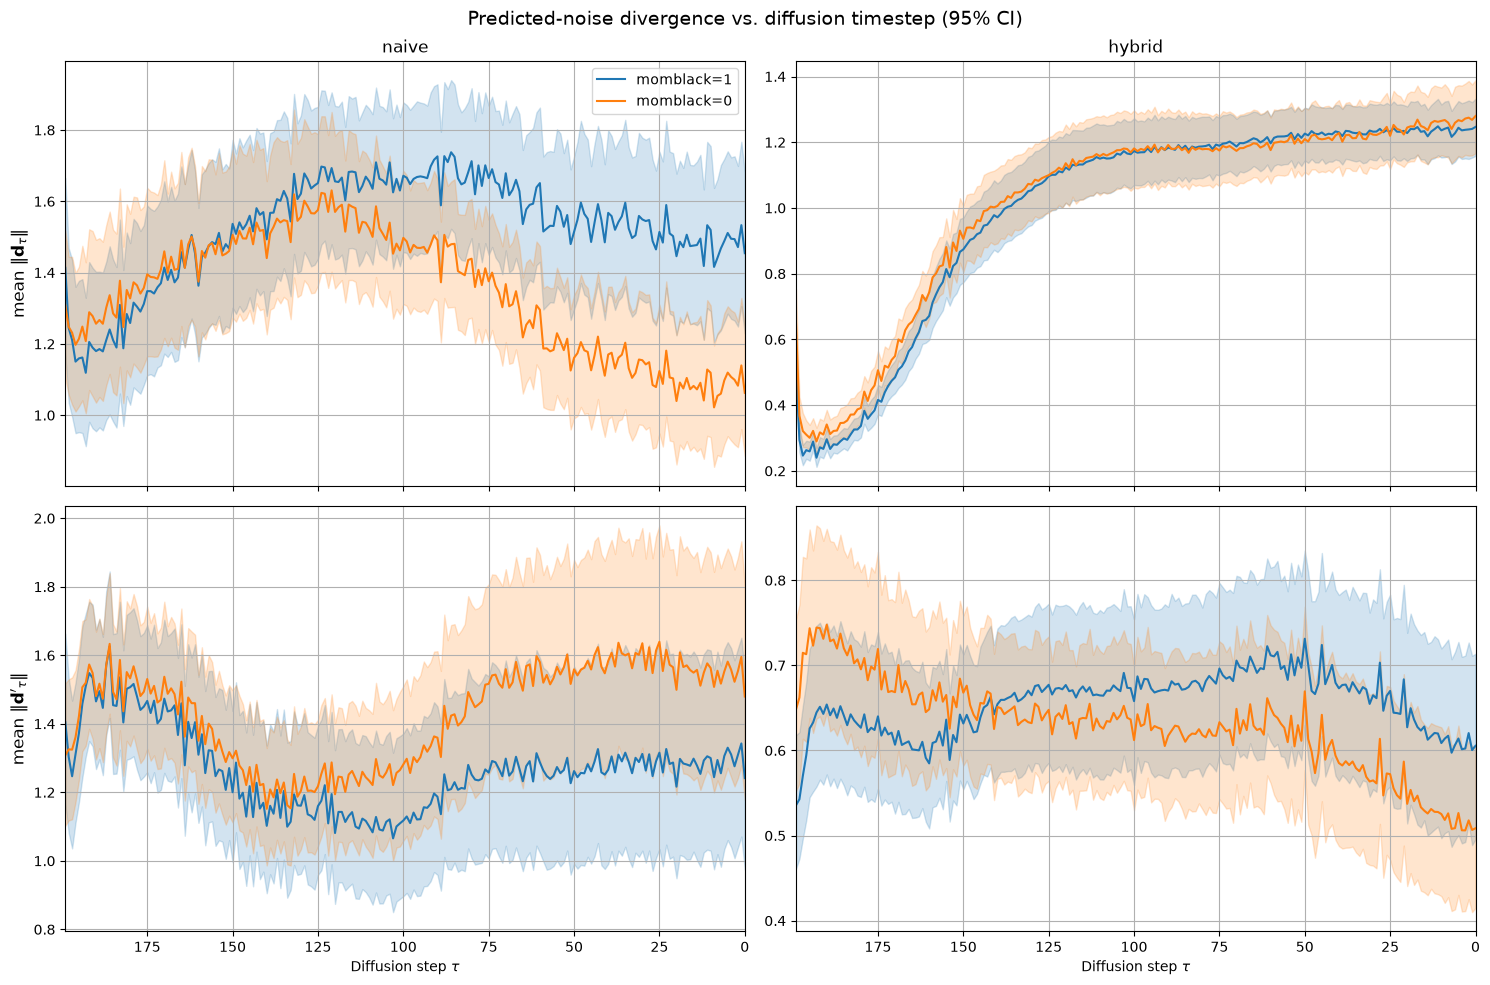

In [40]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharex=True)
for row, key, symbol in [
    (0, "d_tau_norm", r"\mathbf{d}_\tau"),
    (1, "d_tau_prime_norm", r"\mathbf{d}'_\tau"),
]:
    for col, name in enumerate(RESULTS):
        ax = axes[row, col]
        vals = RESULTS[name][key].numpy()
        for mask, label, colour in [(fm, "momblack=1", "C0"), (cm, "momblack=0", "C1")]:
            boot = bootstrap_curve(vals[:, mask], N_BOOT, np.random.default_rng(SEED))
            lo, hi = pointwise_ci(boot)
            ax.plot(tau_axis, vals[:, mask].mean(axis=1), color=colour, label=label)
            ax.fill_between(tau_axis, lo, hi, color=colour, alpha=0.2)
        ax.set_xlim(tau_axis.max(), tau_axis.min())
        ax.grid()
        if row == 0:
            ax.set_title(name)
        else:
            ax.set_xlabel(r"Diffusion step $\tau$")
        if col == 0:
            ax.set_ylabel(rf"mean $\|{symbol}\|$", fontsize=12)
        if row == 0 and col == 0:
            ax.legend()
fig.suptitle("Predicted-noise divergence vs. diffusion timestep (95% CI)", fontsize=14)
fig.tight_layout()
fig.savefig("images/confounding_divergence_vs_tau.png", dpi=150)
plt.show()

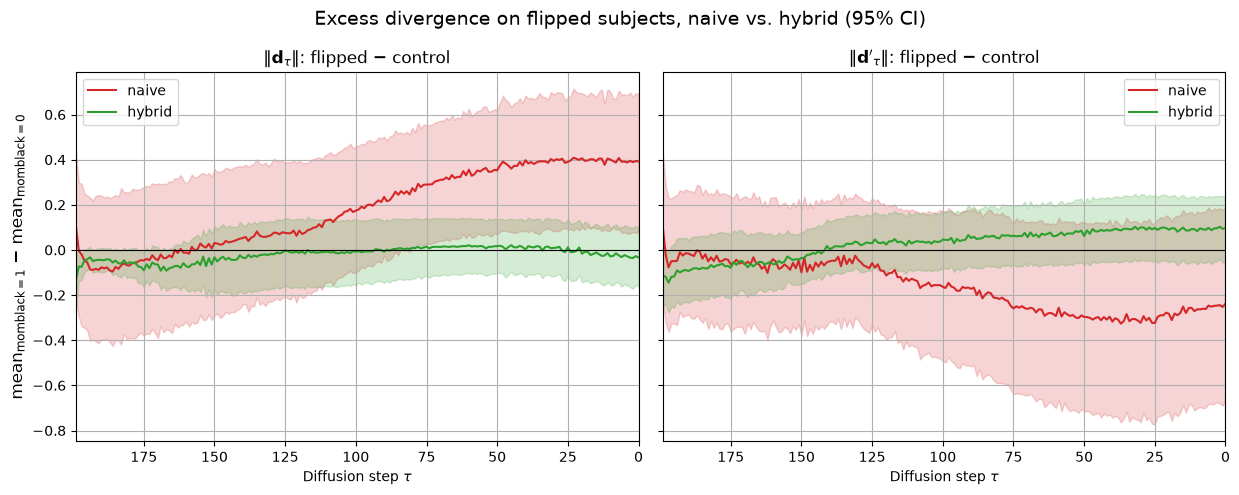

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 5), sharey=True)
for ax, key, symbol in [
    (axes[0], "d_tau_norm", r"\mathbf{d}_\tau"),
    (axes[1], "d_tau_prime_norm", r"\mathbf{d}'_\tau"),
]:
    for name, colour in [("naive", "C3"), ("hybrid", "C2")]:
        vals = RESULTS[name][key].numpy()
        rng = np.random.default_rng(SEED)
        diff_boot = bootstrap_curve(vals[:, fm], N_BOOT, rng) - bootstrap_curve(vals[:, cm], N_BOOT, rng)
        lo, hi = pointwise_ci(diff_boot)
        obs = vals[:, fm].mean(axis=1) - vals[:, cm].mean(axis=1)
        ax.plot(tau_axis, obs, color=colour, label=name)
        ax.fill_between(tau_axis, lo, hi, color=colour, alpha=0.2)
    ax.axhline(0.0, color="k", lw=0.8)
    ax.set_xlim(tau_axis.max(), tau_axis.min())
    ax.set_xlabel(r"Diffusion step $\tau$")
    ax.set_title(rf"$\|{symbol}\|$: flipped $-$ control")
    ax.grid()
    ax.legend()
axes[0].set_ylabel(
    r"mean$_{\mathrm{momblack}=1}$ $-$ mean$_{\mathrm{momblack}=0}$", fontsize=12
)
fig.suptitle("Excess divergence on flipped subjects, naive vs. hybrid (95% CI)", fontsize=14)
fig.tight_layout()
fig.savefig("images/confounding_divergence_diff_vs_tau.png", dpi=150)
plt.show()

## Claim 3: does the footprint predict harm?

Per family: per-subject divergence (sum over tau of `||d_tau||`) vs. the confounded model's
point-estimate error, three ways -- within-group Pearson r; OLS `err ~ divergence * momblack`
with HC3 robust SEs (divergence grand-centred, so `momblack` is the group gap at mean
divergence and the interaction is the slope difference); and a permutation test on the
between-group divergence difference. `err_clean` is run through the same OLS as a negative
control: divergence should predict `err_conf` but not `err_clean` if it tracks
confounding-specific harm rather than intrinsic subject difficulty.

`err_conf` is a K=50 Monte-Carlo estimate, so it carries estimation noise in the regression's
outcome -- this attenuates the correlations without biasing the slopes.

[naive] momblack=0: within-group Pearson r = -0.144 (p=0.226, n=73)
[naive] momblack=1: within-group Pearson r = +0.117 (p=0.318, n=75)


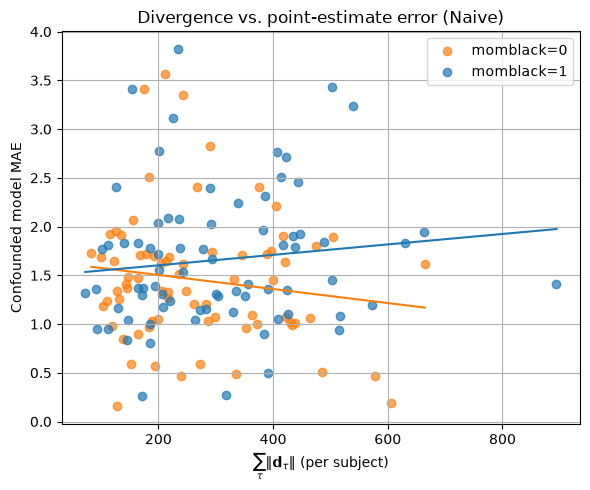


[naive] OLS  err_conf ~ divergence_centred * momblack  (HC3 SEs)
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept                       1.4405      0.080     17.980      0.000       1.283       1.597
divergence_centred             -0.0007      0.001     -1.256      0.209      -0.002       0.000
momblack                        0.2090      0.116      1.807      0.071      -0.018       0.436
divergence_centred:momblack     0.0013      0.001      1.615      0.106      -0.000       0.003

[naive] OLS  err_clean (NEGATIVE CONTROL) ~ divergence_centred * momblack  (HC3 SEs)
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept                       0.8055      0.054     14.877      0.000       0.

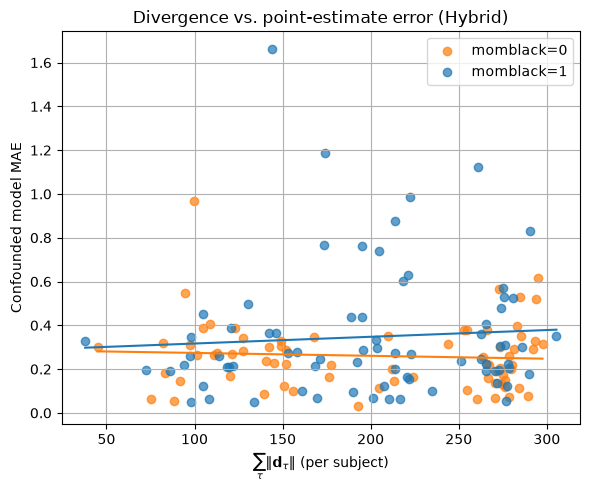


[hybrid] OLS  err_conf ~ divergence_centred * momblack  (HC3 SEs)
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept                       0.2607      0.019     14.045      0.000       0.224       0.297
divergence_centred             -0.0001      0.000     -0.476      0.634      -0.001       0.000
momblack                        0.0872      0.039      2.248      0.025       0.011       0.163
divergence_centred:momblack     0.0004      0.000      0.887      0.375      -0.001       0.001

[hybrid] OLS  err_clean (NEGATIVE CONTROL) ~ divergence_centred * momblack  (HC3 SEs)
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept                       0.4109      0.029     14.140      0.000       

In [42]:
for name, res in RESULTS.items():
    div = res["subject_divergence"].numpy()
    err_c = res["err_conf"].numpy()
    err_0 = res["err_clean"].numpy()
    mb = fm.astype(float)
    divergence_centred = div - div.mean()

    fig, ax = plt.subplots(figsize=(6, 5))
    for mask, label, colour in [(cm, "momblack=0", "C1"), (fm, "momblack=1", "C0")]:
        ax.scatter(div[mask], err_c[mask], color=colour, alpha=0.7, label=label)
        lr = linregress(div[mask], err_c[mask])
        xs = np.array([div[mask].min(), div[mask].max()])
        ax.plot(xs, lr.intercept + lr.slope * xs, color=colour)
        print(
            f"[{name}] {label}: within-group Pearson r = {lr.rvalue:+.3f} "
            f"(p={lr.pvalue:.3g}, n={int(mask.sum())})"
        )
    ax.set_xlabel(r"$\sum_\tau \|\mathbf{d}_\tau\|$ (per subject)")
    ax.set_ylabel("Confounded model MAE")
    ax.set_title(f"Divergence vs. point-estimate error ({name.title()})")
    ax.legend()
    ax.grid()
    fig.tight_layout()
    fig.savefig(f"images/confounding_divergence_vs_error_{name}.png", dpi=150)
    plt.show()

    for tag, err_y in [("err_conf", err_c), ("err_clean (NEGATIVE CONTROL)", err_0)]:
        df = pd.DataFrame(
            {"err": err_y, "divergence_centred": divergence_centred, "momblack": mb}
        )
        ols = smf.ols("err ~ divergence_centred * momblack", data=df).fit(cov_type="HC3")
        print(f"\n[{name}] OLS  {tag} ~ divergence_centred * momblack  (HC3 SEs)")
        print(ols.summary().tables[1])

    perm = permutation_test(
        (div[fm], div[cm]),
        lambda a, b, axis: a.mean(axis=axis) - b.mean(axis=axis),
        permutation_type="independent",
        alternative="two-sided",
        n_resamples=N_PERM,
        rng=SEED,
    )
    print(
        f"\n[{name}] permutation test -- mean divergence (flipped - control): "
        f"diff = {perm.statistic:+.3f}, p = {perm.pvalue:.4g}\n"
    )

## Headline comparison: is the hybrid footprint smaller?

The ratio `mean||d_tau^hybrid|| / mean||d_tau^naive||` (overall and by group), and a paired
permutation test on per-subject total divergence -- same subjects, same `y_init`, so the
pairing is valid.

In [12]:
dn_naive = RESULTS["naive"]["d_tau_norm"]
dn_hybrid = RESULTS["hybrid"]["d_tau_norm"]
print("mean||d_tau^hybrid|| / mean||d_tau^naive||")
for label, mask in groups:
    ratio = (dn_hybrid[:, mask].mean() / dn_naive[:, mask].mean()).item()
    print(f"  {label:11s} {ratio:.4f}")

sd_naive = RESULTS["naive"]["subject_divergence"].numpy()
sd_hybrid = RESULTS["hybrid"]["subject_divergence"].numpy()
paired = permutation_test(
    (sd_hybrid, sd_naive),
    lambda a, b, axis: (a - b).mean(axis=axis),
    permutation_type="samples",
    alternative="less",
    n_resamples=N_PERM,
    rng=SEED,
)
print(
    f"\npaired permutation test -- per-subject (hybrid - naive) total divergence: "
    f"mean diff = {paired.statistic:+.3f}, p(hybrid < naive) = {paired.pvalue:.4g}"
)

mean||d_tau^hybrid|| / mean||d_tau^naive||
  overall     0.6988
  momblack=1  0.6515
  momblack=0  0.7539

paired permutation test -- per-subject (hybrid - naive) total divergence: mean diff = -86.561, p(hybrid < naive) = 9.999e-05


## z-collapse diagnostic

If the hybrid footprint does not shrink, one explanation is that the encoder collapsed toward
the prior, so `HybridModel` behaves like `DiffPO`. This compares the clean and confounded
hybrid encoders' posterior means on the subset.

In [13]:
hyb_clean, hyb_conf = RESULTS["hybrid"]["clean"], RESULTS["hybrid"]["conf"]
with torch.no_grad():
    mu_clean, sig_clean = hyb_clean.encoder.forward(
        x, a_clean, hyb_clean.aux_outcome.mean(x, a_clean)
    )
    mu_conf, sig_conf = hyb_conf.encoder.forward(
        x, a_conf, hyb_conf.aux_outcome.mean(x, a_conf)
    )

print("hybrid encoder posterior means (prior is N(0, I)):")
print(f"  mean ||mu_clean - mu_conf||  = {(mu_clean - mu_conf).norm(dim=1).mean():.4f}")
print(f"  mean ||mu_clean||            = {mu_clean.norm(dim=1).mean():.4f}")
print(f"  mean ||mu_conf||             = {mu_conf.norm(dim=1).mean():.4f}")
print(f"  mean sigma_clean             = {sig_clean.mean():.4f}  (prior 1.0)")
print(f"  mean sigma_conf              = {sig_conf.mean():.4f}  (prior 1.0)")

lat = mu_clean.shape[1]
corr = np.abs(np.corrcoef(mu_clean.T.numpy(), x.T.numpy())[:lat, lat:])
top = np.unravel_index(corr.argmax(), corr.shape)
print(
    f"  max |corr(mu_clean latent dim, covariate)| = {corr.max():.3f} "
    f"(latent {top[0]}, covariate column {top[1]})"
)

hybrid encoder posterior means (prior is N(0, I)):
  mean ||mu_clean - mu_conf||  = 0.4977
  mean ||mu_clean||            = 2.4302
  mean ||mu_conf||             = 2.4218
  mean sigma_clean             = 0.8029  (prior 1.0)
  mean sigma_conf              = 0.8023  (prior 1.0)
  max |corr(mu_clean latent dim, covariate)| = 0.873 (latent 14, covariate column 0)


## Density surface visualisation

For each family, one `momblack==1` and one `momblack==0` subject: a KDE density surface of
y_tau at several snapshot taus, clean vs. confound rows. Built from the stochastic DDPM
sampler (`sample_trajectory`), not the deterministic DDIM path -- a single DDIM trajectory
can't produce a distribution. The score vector field also originally plotted was dropped (near-constant across tau) as I couldn't get the arrows to behave.

In [14]:
L_STEPS = cfg.diffusion.num_steps
SNAPSHOT_TAUS = [L_STEPS - 1, 3 * L_STEPS // 4, L_STEPS // 2, L_STEPS // 4, 0]
DENSITY_K = 300
GRID_N = 70
GRID_RANGE = 7.0  # y0, y1 span, in normalised outcome units

subject_flipped = int(np.flatnonzero(flipped_mask.numpy())[0])
subject_control = int(np.flatnonzero(control_mask.numpy())[0])


def tau_to_traj_index(tau: int, L: int) -> int:
    """Trajectory index i logs tau = L-1-i (see _ddim_reverse/_ddpm_reverse docstrings)."""
    return (L - 1) - tau

In [19]:
def sample_trajectory(
    model: _DiffusionBase,
    x_subj: torch.Tensor,
    a_subj: torch.Tensor,
    clip_val: float,
    seed: int = SEED,
    K: int = DENSITY_K,
) -> torch.Tensor:
    """K stochastic DDPM reverse-trajectory samples for one subject.

    Conditioning comes from model.encode_cond (deterministic), so all K trajectories share
    the latent and only the DDPM noise varies. Returns y_traj (L, K, 2); slice a snapshot
    with tau_to_traj_index.
    """
    cond = model.encode_cond(x_subj.unsqueeze(0), a_subj.unsqueeze(0)).expand(K, -1)
    a_rep = a_subj.unsqueeze(0).expand(K)
    torch.manual_seed(seed)
    with torch.no_grad():
        _, y_traj, _ = model._ddpm_reverse(
            K, cond, a_rep, torch.device("cpu"), clip_val=clip_val, log_trajectory=True
        )
    return y_traj


def kde_surface(
    samples: torch.Tensor, grid_n: int = GRID_N, grid_range: float = GRID_RANGE
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Fit a 2D Gaussian KDE to `samples` (K, 2) and evaluate on a regular grid.

    Returns (Y0, Y1, Z) each (grid_n, grid_n), aligned for ax.plot_surface.
    """
    kde = gaussian_kde(samples.numpy().T)
    lin = np.linspace(-grid_range, grid_range, grid_n)
    Y0, Y1 = np.meshgrid(lin, lin)
    Z = kde(np.vstack([Y0.ravel(), Y1.ravel()])).reshape(grid_n, grid_n)
    return Y0, Y1, Z


def plot_density_surface(
    model: _DiffusionBase, tau: int, title: str, ax: Axes3D, y_traj_samples: torch.Tensor
) -> None:
    """KDE density surface of y_tau for one (model, subject, tau)."""
    samples = y_traj_samples[tau_to_traj_index(tau, model.L)]  # (K, 2)
    y0_grid, y1_grid, p_hat = kde_surface(samples)
    ax.plot_surface(y0_grid, y1_grid, p_hat, cmap="viridis")
    ax.set_title(title, y=0.99)
    ax.set_xlabel(r"$y(0)$")
    ax.set_ylabel(r"$y(1)$")
    ax.set_zlabel(r"$\hat p_\tau(y)$")

/home/justin/msc_ai/individual-project/diffusion-irregular-ehr/.venv/lib/python3.14/site-packages/mpl_toolkits/mplot3d/proj3d.py:184: RuntimeWarning: overflow encountered in dot
  product = np.dot(axes.M, vec)


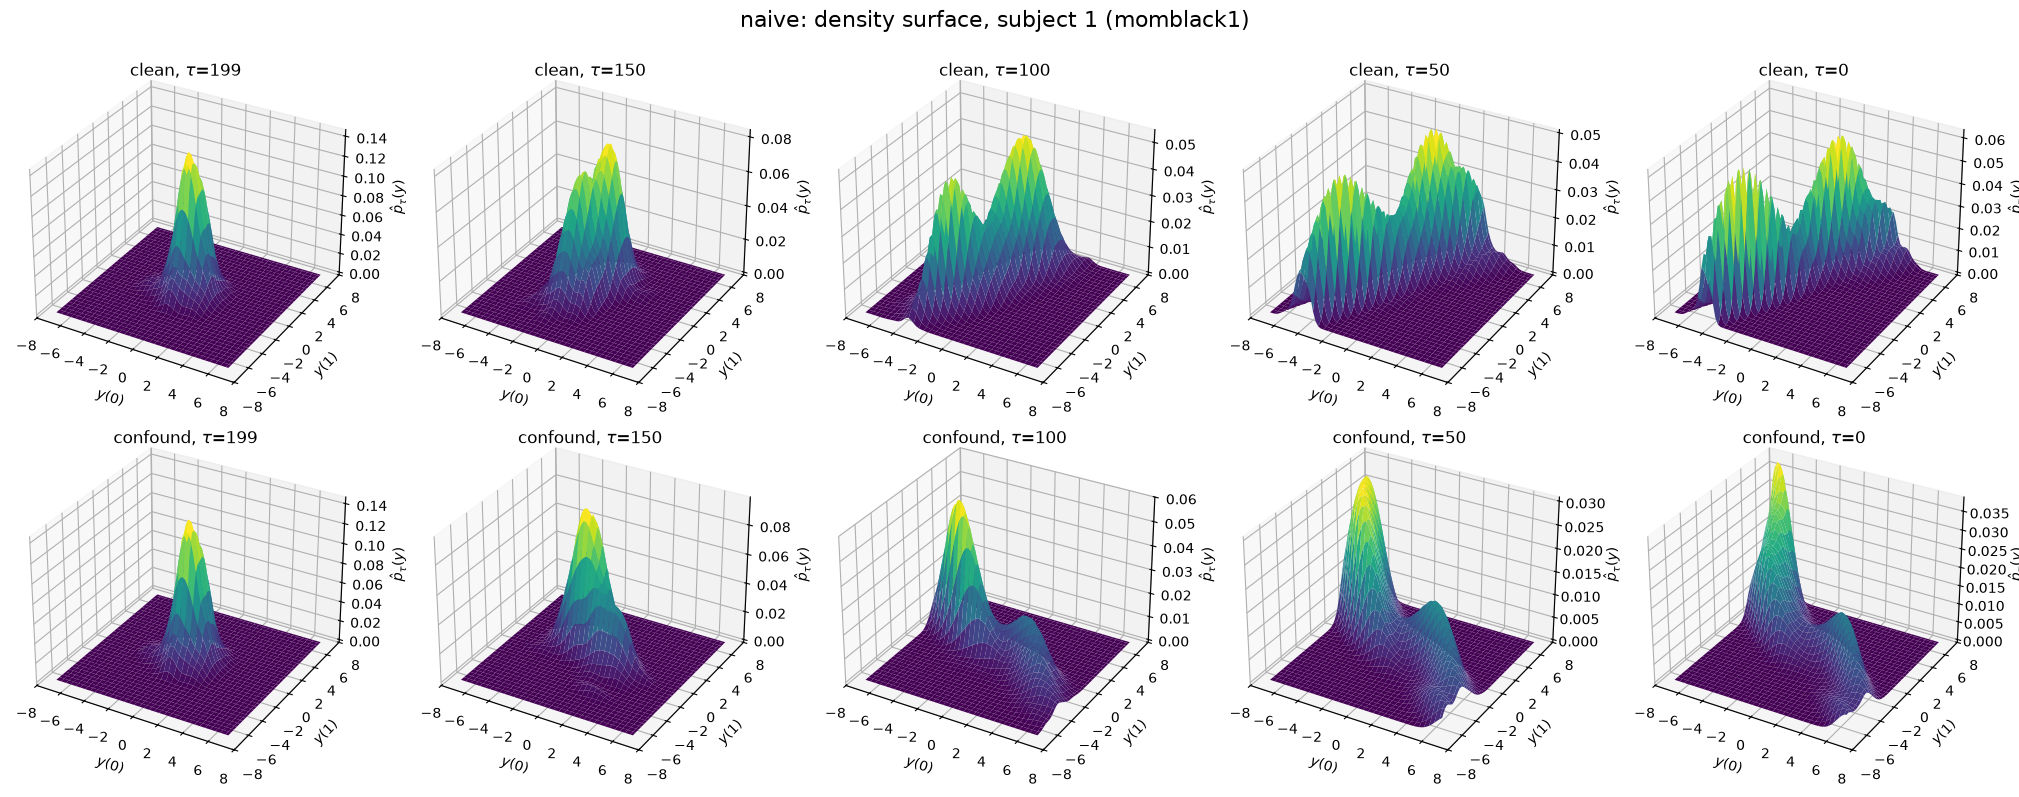

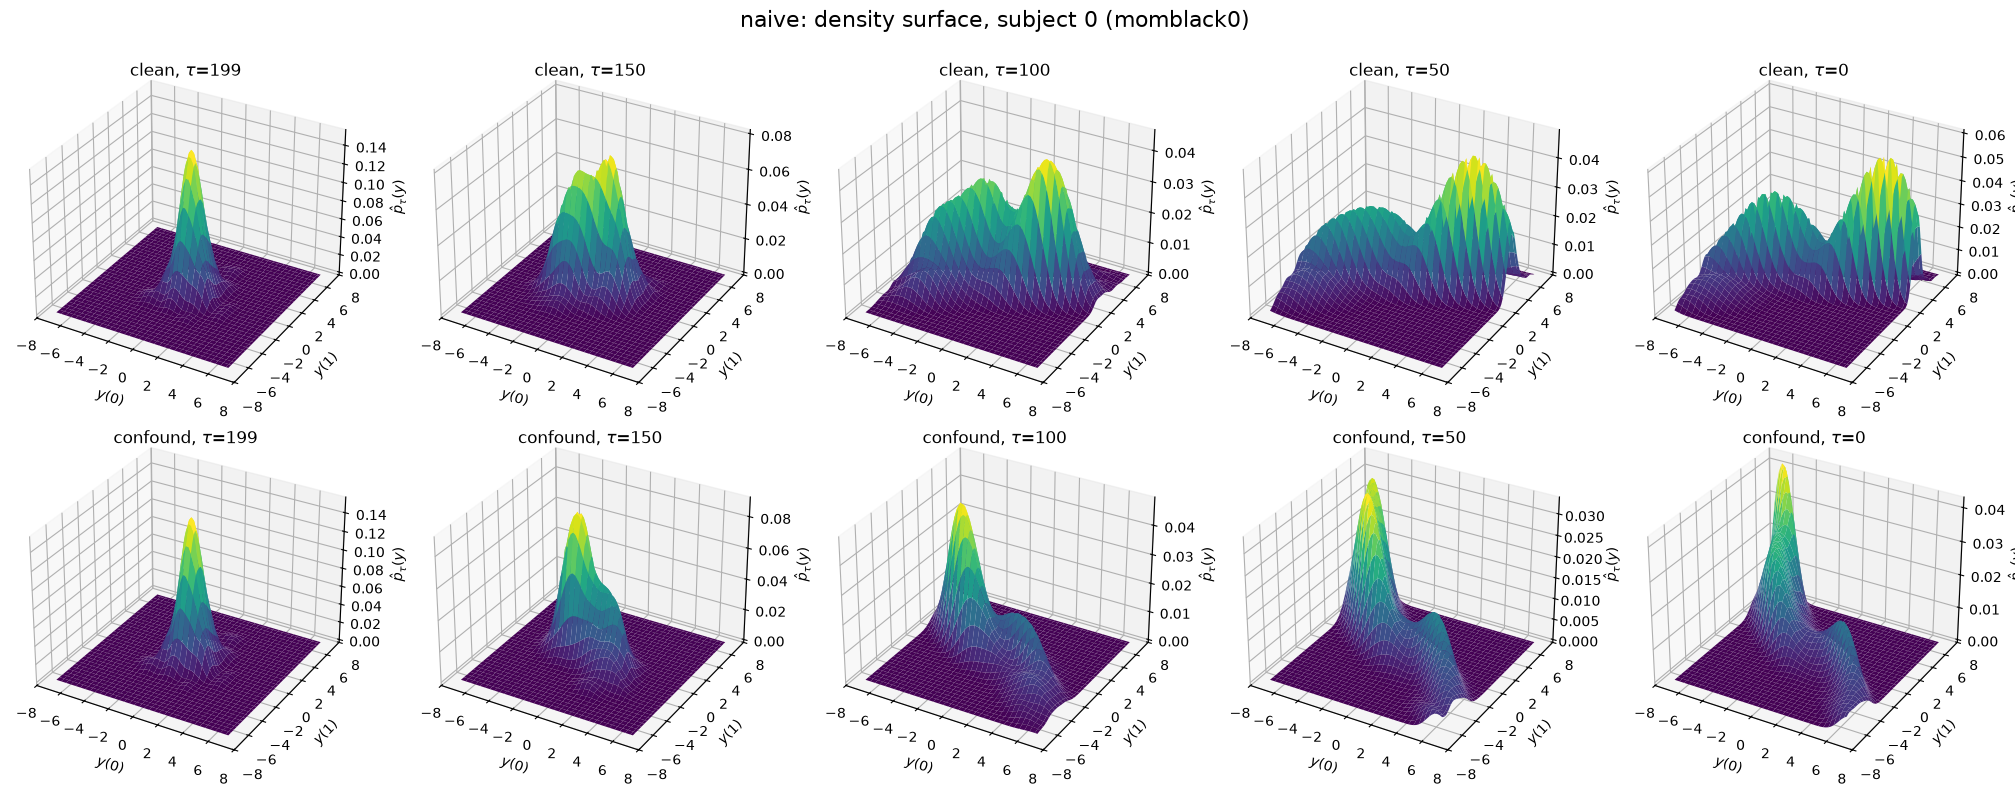

/home/justin/msc_ai/individual-project/diffusion-irregular-ehr/.venv/lib/python3.14/site-packages/mpl_toolkits/mplot3d/proj3d.py:184: RuntimeWarning: overflow encountered in dot
  product = np.dot(axes.M, vec)


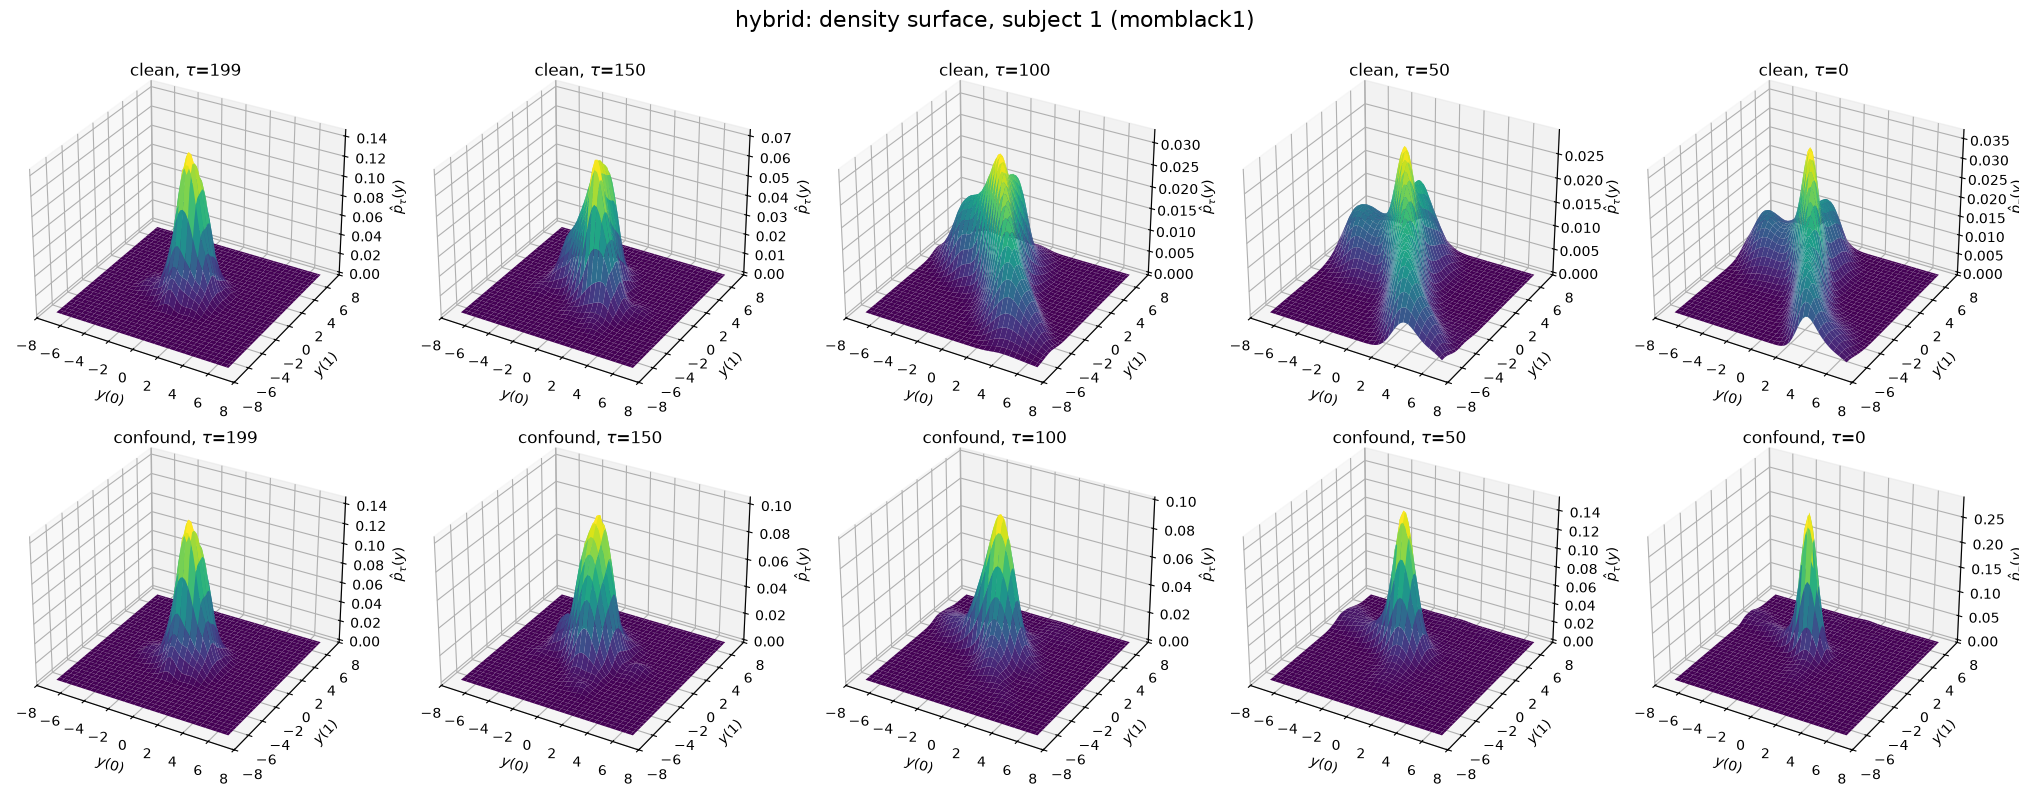

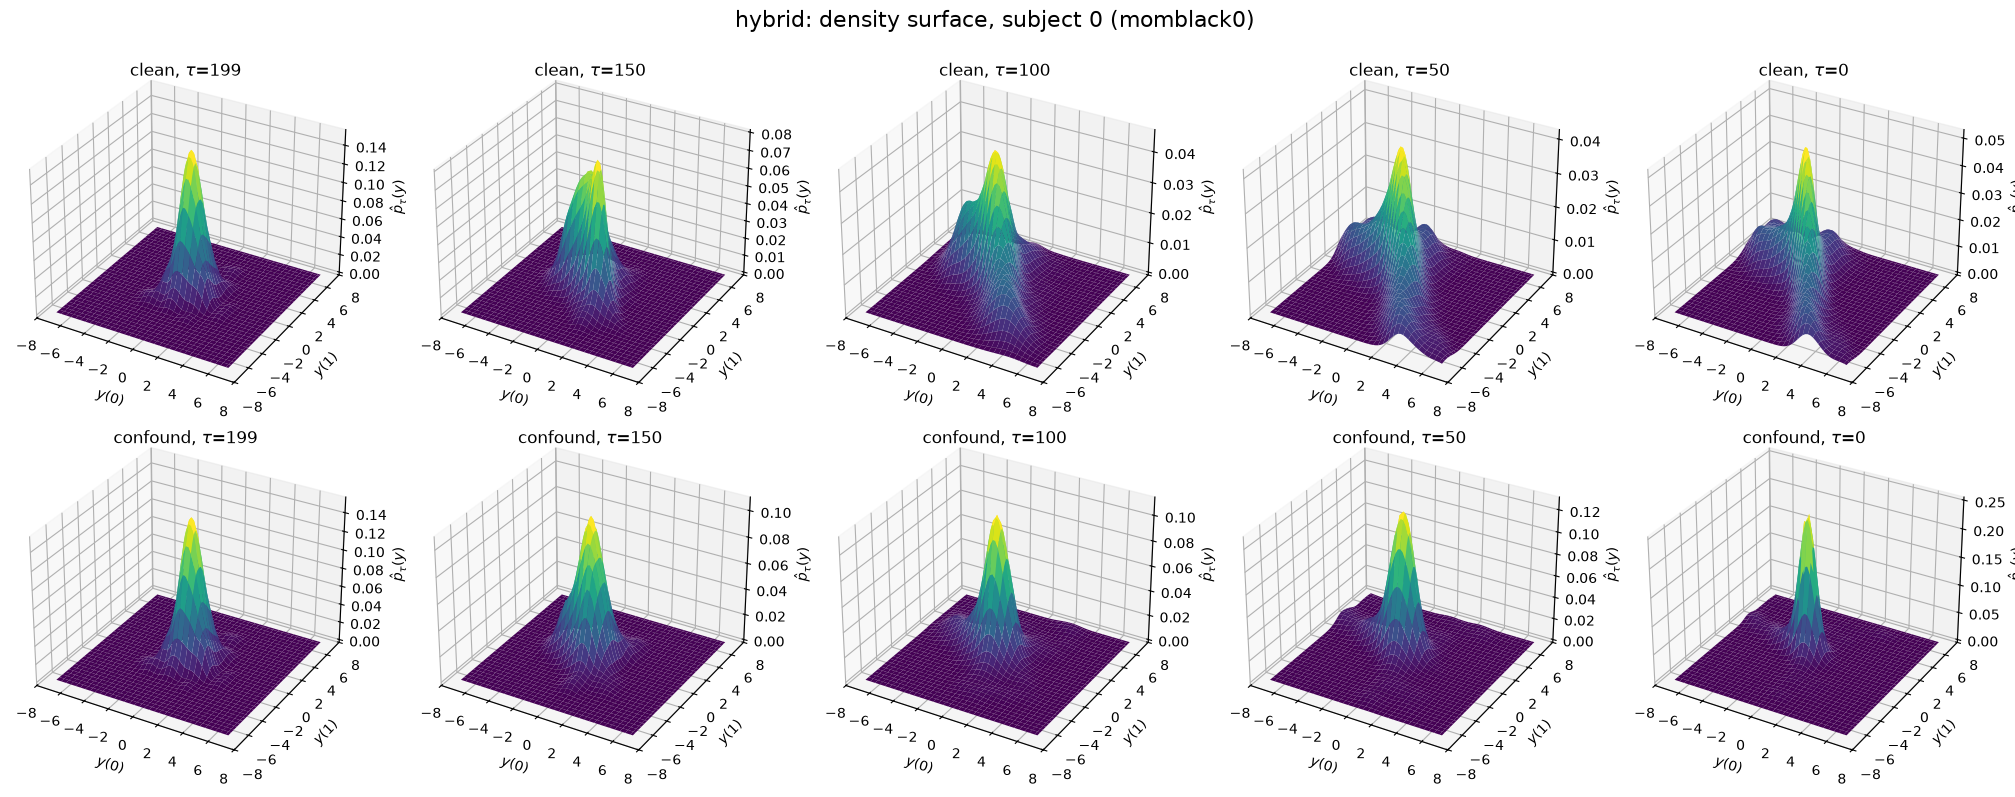

In [20]:
for name, res in RESULTS.items():
    for subj_idx, subj_label in [
        (subject_flipped, "momblack1"),
        (subject_control, "momblack0"),
    ]:
        x_subj = x[subj_idx]
        a_clean_subj, a_conf_subj = a_clean[subj_idx], a_conf[subj_idx]
        run_seed = SEED + subj_idx
        clean_traj = sample_trajectory(
            res["clean"], x_subj, a_clean_subj, clip_value_clean, run_seed
        )
        conf_traj = sample_trajectory(
            res["conf"], x_subj, a_conf_subj, clip_value_conf, run_seed
        )

        fig = plt.figure(figsize=(4 * len(SNAPSHOT_TAUS), 8))
        for col, tau in enumerate(SNAPSHOT_TAUS):
            ax_c = fig.add_subplot(2, len(SNAPSHOT_TAUS), col + 1, projection="3d")
            plot_density_surface(R["clean"], tau, rf"clean, $\tau$={tau}", ax_c, clean_traj)
            ax_k = fig.add_subplot(
                2, len(SNAPSHOT_TAUS), len(SNAPSHOT_TAUS) + col + 1, projection="3d"
            )
            plot_density_surface(R["conf"], tau, rf"confound, $\tau$={tau}", ax_k, conf_traj)
        fig.suptitle(
            f"{name}: density surface, subject {subj_idx} ({subj_label})", fontsize=16
        )
        fig.tight_layout()
        fig.subplots_adjust(wspace=0.15)
        fig.savefig(
            f"images/confounding_density_{name}_{subj_label}.png",
            dpi=150,
            bbox_inches="tight",
        )
        plt.show()